### Imports

In [1]:
import os, json, sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LinearLocator, FormatStrFormatter
import seaborn as sns

### Load experiment data

In [2]:
results_dir = "../outputs/experiment_results"

with open(os.path.join(results_dir, "results_mnist_fcnn_inf.json"), "r") as f:
    results_mnist_fcnn_inf = json.load(f)

with open(os.path.join(results_dir, "results_cifar10_cnn_inf.json"), "r") as f:
    results_cifar10_cnn_inf = json.load(f)

### Plot

In [3]:
true_output_diffs_fcnn = np.asarray(results_mnist_fcnn_inf["true_output_diffs_at_Xt"])
est_output_diffs_fcnn = np.asarray(results_mnist_fcnn_inf["est_output_diffs_at_Xt"])
true_output_diffs_cnn = np.asarray(results_cifar10_cnn_inf["true_output_diffs_at_Xt"])
est_output_diffs_cnn = np.asarray(results_cifar10_cnn_inf["est_output_diffs_at_Xt"])

true_loss_diffs_fcnn = np.asarray(results_mnist_fcnn_inf["true_loss_diffs_at_Xt"])
est_loss_diffs_fcnn = np.asarray(results_mnist_fcnn_inf["est_loss_diffs_at_Xt"])
true_loss_diffs_cnn = np.asarray(results_cifar10_cnn_inf["true_loss_diffs_at_Xt"])
est_loss_diffs_cnn = np.asarray(results_cifar10_cnn_inf["est_loss_diffs_at_Xt"])

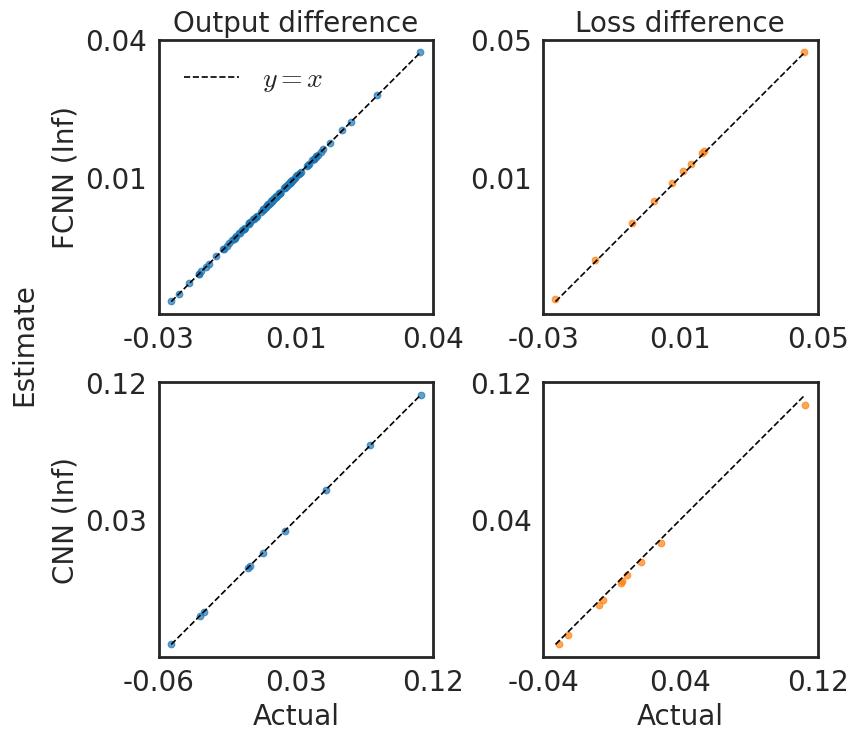

In [6]:
figures_dir = "../outputs/figures"
os.makedirs(figures_dir, exist_ok=True)

rc_tex = {
    "text.usetex": False,
    "mathtext.fontset": "cm",
}

rng = np.random.default_rng(1)
num_samples = 10

with plt.rc_context(rc_tex), sns.axes_style("white"), sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(2, 2, figsize=(8.5, 8.5))

    title_fs = 20
    label_fs = 20
    tick_fs = 20
    legend_fs = 20

    def plot_panel(ax, true_diff, est_diff, color, show_legend=False):
        sampled_idx = rng.choice(
            true_diff.shape[0],
            size=min(num_samples, true_diff.shape[0]),
            replace=False,
        )

        x = true_diff[sampled_idx].reshape(-1)
        y = est_diff[sampled_idx].reshape(-1)

        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())

        ax.scatter(x, y, alpha=0.7, color=color)
        ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", label=r"$y=x$")
        ax.set_aspect("equal", adjustable="box")

        if show_legend:
            ax.legend(frameon=False, fontsize=legend_fs, loc="best")

    # -------------------------
    # Row 1: FCNN
    # -------------------------
    plot_panel(
        axes[0, 0],
        true_output_diffs_fcnn,
        est_output_diffs_fcnn,
        color="tab:blue",
        show_legend=True,
    )
    axes[0, 0].set_title("Output difference", fontsize=title_fs)
    axes[0, 0].set_ylabel("FCNN (Inf)", fontsize=label_fs)

    plot_panel(
        axes[0, 1],
        true_loss_diffs_fcnn,
        est_loss_diffs_fcnn,
        color="tab:orange",
        show_legend=False,
    )
    axes[0, 1].set_title("Loss difference", fontsize=title_fs)

    # -------------------------
    # Row 2: CNN
    # -------------------------
    plot_panel(
        axes[1, 0],
        true_output_diffs_cnn,
        est_output_diffs_cnn,
        color="tab:blue",
        show_legend=False,
    )
    axes[1, 0].set_ylabel("CNN (Inf)", fontsize=label_fs)

    plot_panel(
        axes[1, 1],
        true_loss_diffs_cnn,
        est_loss_diffs_cnn,
        color="tab:orange",
        show_legend=False,
    )

    # Bottom x-labels
    axes[1, 0].set_xlabel("Actual", fontsize=label_fs)
    axes[1, 1].set_xlabel("Actual", fontsize=label_fs)

    # Shared y-label
    fig.supylabel("Estimate", fontsize=label_fs, x=-0.05)
    #fig.supxlabel("Actual", fontsize=label_fs)

    for ax in axes.flat:
        # ax.xaxis.set_major_locator(MaxNLocator(nbins=2))
        # ax.yaxis.set_major_locator(MaxNLocator(nbins=2))
        ax.xaxis.set_major_locator(LinearLocator(numticks=3))
        ax.yaxis.set_major_locator(LinearLocator(numticks=3))
        ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

        for spine in ax.spines.values():
            spine.set_linewidth(2.0)

        ax.tick_params(axis="both", labelsize=tick_fs, width=1.5)
        ax.get_yticklabels()[0].set_visible(False)

    fig.subplots_adjust(hspace=0.1, wspace=0.4)

    fig.savefig(os.path.join(figures_dir, "figure_4.pdf"), bbox_inches="tight")

    plt.show()